In [10]:
import pandas as pd
import numpy as np
import os, sys
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
import seaborn as sns
import re, math
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.patches import ConnectionPatch
from matplotlib.ticker import MultipleLocator, FormatStrFormatter
from pathlib import Path
from brokenaxes import brokenaxes
import datetime

ROOT = '/home/wychen/workspace/vllm-dynamic/scripts'
DATASET_PATH=f'{ROOT}/dataset/slo'
PDF_PATH=f'{ROOT}/pdf'
line_styles = ['-', '--', '-.', ':', 'solid', 'dashed', 'dashdot', 'dotted', '-', '--', '-.', ':', 'solid', 'dashed', 'dashdot', 'dotted']
markers = ['o', 's', 'D', '^', 'v', 'x', '+', '1', '2', '3', '4', '8', 'p', '*', 'h', 'H', '<', '>', 'd']
hatches = hatches = ['...', '--', '///', '\\\\\\', '+', 'x', 'o', 'O', '.', '*', '0', '1', '2', '3', '4', '5', '6', '7', '8']

In [5]:
# 1. 读入文本：支持文件路径或 stdin
def load_text(src: str | None = None) -> str:
    if src is None:                      # 默认从 stdin 读
        return sys.stdin.read()
    path = Path(src)
    if path.exists():                    # 文件路径
        return path.read_text(encoding="utf8")
    return src                           # 直接当成字符串

# 2. 提取并求平均
def extract_avg_ttft(text: str) -> dict[str, float]:
    # 正则抓“关键字 + 冒号/空格 + 数字”
    pattern = re.compile(
        r"^\s*(Mean|Median|P99)\s+TTFT\s*\(ms\)\s*:\s*([\d\.]+)\s*$", re.M
    )
    buckets = {"Mean": [], "Median": [], "P99": []}
    for key, val in pattern.findall(text):
        buckets[key].append(float(val))

    return {k: sum(v) / len(v) if v else math.nan for k, v in buckets.items()}

def parse_log_file(file_path: str) -> dict[str, float]:
    text = load_text(file_path)
    return extract_avg_ttft(text)

In [ ]:
prompt_nums = [793, 1553, 2346, 3106, 3899, 4659]
scales = [0.5, 1, 1.5, 2, 2.5, 3]
data_name = 'paper_assistant'
model_name = 'meta-llama_Llama-2-13b-chat-hf'
system_name = 'ellm'
gpu_num = 1
# 将所有数据读入一个 DataFrame
all_df = None
for i, prompt_num in enumerate(prompt_nums):
    scale = scales[i]
    records = []
    if 'swap' in system_name:
        log_path = f'{DATASET_PATH}/{system_name}/{data_name}/{model_name}_client_{prompt_num}_swap_{gpu_num}gpu.log'
    else:    
        log_path = f'{DATASET_PATH}/{system_name}/{data_name}/{model_name}_client_{prompt_num}_recompute_{gpu_num}gpu.log'
    if not os.path.exists(log_path):
        print(f'Warning: {log_path} not exists, skip.')
        continue
    metrics = parse_log_file(log_path)
    metrics['scale'] = scale
    records.append(metrics)
    df = pd.DataFrame(records)
    df['prompt_num'] = prompt_num
    if prompt_num == prompt_nums[0]:
        all_df = df
    else:
        all_df = pd.concat([all_df, df], ignore_index=True)
all_df['model_name'] = model_name
all_df['system_name'] = system_name
# 将这两列放到最前面
all_df = all_df[['model_name', 'system_name', 'prompt_num', 'scale', 'Mean', 'Median', 'P99']]
# 追加写入 CSV
all_df.to_csv(f'{DATASET_PATH}/e2e_various_loads_ttft_13b_new.csv', index=False, mode='a', header=not os.path.exists(f'{DATASET_PATH}/e2e_various_loads_ttft_13b_new.csv')) 
# 对于重复的行，取平均
all_df = all_df.groupby(['model_name', 'system_name', 'prompt_num', 'scale'], as_index=False).mean()
print(all_df)

                       model_name system_name  prompt_num  scale  \
0  meta-llama_Llama-2-13b-chat-hf        ellm         793    0.5   
1  meta-llama_Llama-2-13b-chat-hf        ellm        1553    1.0   
2  meta-llama_Llama-2-13b-chat-hf        ellm        2346    1.5   
3  meta-llama_Llama-2-13b-chat-hf        ellm        3106    2.0   
4  meta-llama_Llama-2-13b-chat-hf        ellm        3899    2.5   
5  meta-llama_Llama-2-13b-chat-hf        ellm        4659    3.0   

           Mean      Median           P99  
0  4.730236e+05   479102.40  9.437291e+05  
1  1.524316e+06  1531527.13  3.036495e+06  
2  2.533766e+06  2556442.92  4.882337e+06  
3  3.577986e+06  3676732.28  6.716399e+06  
4  4.945105e+06  5138738.02  9.333318e+06  
5  6.129646e+06  6363292.43  1.119644e+07  


In [22]:
# plot the P99 TTFT vs scale
def plot_p99_ttft_vs_scale(input_path: str, save_path: str):
    df = pd.read_csv(input_path)
    # normalized to P99 of ellm
    norm_base_value = df[(df['system_name'] == 'ellm') & (df['model_name'] == model_name) & (df['prompt_num'] == prompt_nums[0])]['P99'].values[0]
    df['norm_p99'] = df['P99'] / norm_base_value
    # print(df)
    system_names = ['vllm-recompute', 'vllm-swap', 'hcache', 'ellm']
    system_labels = ['Recompute', 'Swap', 'HCache', 'eLLM']
    x_labels = ['0.5x', '1x', '1.5x', '2x', '2.5x', '3x']
    metric_label = 'Norm. TTFT'

    fig = plt.figure(figsize=(3, 2), dpi=120)
    ax = fig.add_subplot(111)
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
  
    for i, system_name in enumerate(system_names):
        system_df = df[df['system_name'] == system_name]            
        ax.plot(system_df['scale'], system_df['norm_p99'], marker=markers[i], linestyle=line_styles[i], color=plt.cm.tab20b(i/5), label=system_labels[i], zorder=10, markeredgewidth=1.5, markerfacecolor="none", markeredgecolor=plt.cm.tab20b(i/5))
    ax.set_xlabel('Relative loads')
    ax.set_ylabel(metric_label)
    ax.set_xticklabels(x_labels)
    if len(x_labels) == len(scales):
        ax.set_xticklabels(x_labels)
    ax.set_xticks(scales)
    ax.set_ylim(0, 20)    
    ax.grid(True, axis='y', linestyle='--', linewidth=0.3, zorder=-10)
    ax.legend(loc=(0.05, 0.43), ncol=1, framealpha=1, frameon=False, columnspacing=0.3, labelspacing=0.2, handlelength=1.5, handletextpad=0.2, borderaxespad=0.2, borderpad=0.5)
    plt.tight_layout(pad=0.1, w_pad=0.1, h_pad=0.1)
    model_label = model_name.split('-')[3]
    plt.savefig(f'{PDF_PATH}/various_loads_ttft_{data_name}_{model_label}.pdf', bbox_inches='tight')

/tmp/ipykernel_1715971/448417324.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x_labels)
/tmp/ipykernel_1715971/448417324.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x_labels)


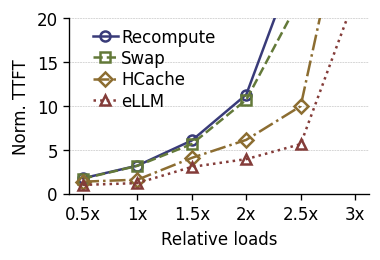

In [40]:
input_csv = f'{DATASET_PATH}/e2e_various_loads_ttft_13b.csv'
output_pdf = f'{PDF_PATH}/e2e_various_loads_ttft_13b.pdf'
plot_p99_ttft_vs_scale(input_csv, output_pdf)

In [29]:
# plot the slo attainment vs scale
def plot_slo_vs_scale(input_path: str, save_path: str):
    df = pd.read_csv(input_path)
    system_names = ['vllm-recompute', 'vllm-swap', 'hcache', 'ellm']
    system_labels = ['Recompute', 'Swap', 'HCache', 'eLLM']
    x_labels = ['0.5x', '1x', '1.5x', '2x', '2.5x', '3x']
    metric_label = 'SLO Attainment (%)'

    fig = plt.figure(figsize=(3, 2), dpi=120)
    ax = fig.add_subplot(111)
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
  
    for i, system_name in enumerate(system_names):
        system_df = df[df['system_name'] == system_name]            
        ax.plot(system_df['scale'], system_df['slo_achieved'], marker=markers[i], linestyle=line_styles[i], color=plt.cm.tab20b(i/5), label=system_labels[i], zorder=10, markeredgewidth=1.5, markerfacecolor="none", markeredgecolor=plt.cm.tab20b(i/5))
    ax.set_xlabel('Relative loads')
    ax.set_ylabel(metric_label)
    ax.set_xticklabels(x_labels)
    if len(x_labels) == len(scales):
        ax.set_xticklabels(x_labels)
    ax.set_xticks(scales)
    ax.set_ylim(60, 100)    
    ax.grid(True, axis='y', linestyle='--', linewidth=0.3, zorder=-10)
    ax.legend(loc=(0.05, 0.1), ncol=2, framealpha=1, frameon=False, columnspacing=0.3, labelspacing=0.2, handlelength=1.5, handletextpad=0.2, borderaxespad=0.2, borderpad=0.5)
    plt.tight_layout(pad=0.1, w_pad=0.1, h_pad=0.1)
    model_label = model_name.split('-')[3]
    plt.savefig(f'{PDF_PATH}/various_loads_slo_attainment_{data_name}_{model_label}.pdf', bbox_inches='tight')

/tmp/ipykernel_1715971/1629442676.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x_labels)
/tmp/ipykernel_1715971/1629442676.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x_labels)


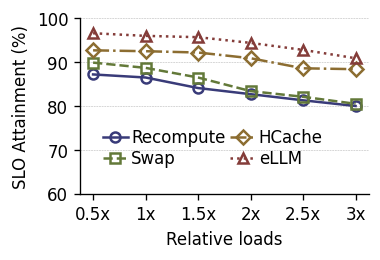

In [39]:
input_csv = f'{DATASET_PATH}/e2e_various_loads_slo_13b.csv'
output_pdf = f'{PDF_PATH}/e2e_various_loads_slo_13b.pdf'
plot_slo_vs_scale(input_csv, output_pdf)